In [1]:
from pathlib import Path
import kagglehub

# Download latest version
path = Path(kagglehub.dataset_download("sagyamthapa/handwritten-math-symbols"))
path = path / "dataset"
print("Path to dataset files:", path)

C:\Users\Alex\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symbols\versions\4\dataset


In [2]:
import pathlib
import os

for dirpath, dirnames, filenames in os.walk(path):
    print(f"path: {dirpath}, directories: {len(dirnames)}, files: {len(filenames)}")

path: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symbols\versions\4\dataset, directories: 19, files: 1
path: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symbols\versions\4\dataset\0, directories: 0, files: 595
path: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symbols\versions\4\dataset\1, directories: 0, files: 562
path: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symbols\versions\4\dataset\2, directories: 0, files: 433
path: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symbols\versions\4\dataset\3, directories: 0, files: 541
path: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symbols\versions\4\dataset\4, directories: 0, files: 526
path: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symbols\versions\4\dataset\5, directories: 0, files: 433
path: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symb

In [3]:
import numpy as np
import torch
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
 
 
class ScaleAndPad:
    def __init__(self, size=32, padding=6, ink_threshold=128):
        self.size = size
        self.padding = padding
        self.usable = size - padding * 2
        self.ink_threshold = ink_threshold
 
    def __call__(self, img):
        arr = np.array(img)
        ys, xs = np.where(arr < self.ink_threshold)
        if len(xs) == 0:
            return img.resize((self.size, self.size))
 
        x0, x1, y0, y1 = xs.min(), xs.max(), ys.min(), ys.max()
        w, h = max(x1 - x0, 1), max(y1 - y0, 1)
        scale = self.usable / max(w, h)
        new_w, new_h = max(1, round(w * scale)), max(1, round(h * scale))
 
        resized = img.crop((x0, y0, x1 + 1, y1 + 1)).resize((new_w, new_h), Image.LANCZOS)
        canvas = Image.new("L", (self.size, self.size), 255)
        canvas.paste(resized, (self.padding + (self.usable - new_w) // 2,
                                self.padding + (self.usable - new_h) // 2))
        return canvas
 
 
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    ScaleAndPad(32, 6),
    transforms.RandomRotation(12),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=4),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1.0 - x),
    transforms.Normalize((0.5,), (0.5,))
])


dataset = datasets.ImageFolder(root=path, transform=transform)
dataset.class_to_idx

definitions = {value: key for key, value in dataset.class_to_idx.items()}
print(definitions)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'add', 11: 'dec', 12: 'div', 13: 'eq', 14: 'mul', 15: 'sub', 16: 'x', 17: 'y', 18: 'z'}


In [4]:
# 80% train & 20% test slice

train_size = int(0.8*len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42)
)



loaders = {
    "train": DataLoader(train_dataset, batch_size=32, shuffle=True),
    "test": DataLoader(test_dataset, batch_size=32, shuffle=False)
}

In [5]:
import torch.nn as nn
import torch.nn.functional as F



class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)


class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1) #change to 1, 32 later
        self.bn1 = nn.BatchNorm2d(32)
        self.res1 = ResidualBlock(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) #32, 64
        self.bn2 = nn.BatchNorm2d(64)
        self.res2 = ResidualBlock(64)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        
        self.dropout_spatial = nn.Dropout2d(0.1)
        self.dropout_dense = nn.Dropout(0.3)
        
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 19)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.res1(x)
        x = self.dropout_spatial(x)

        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.res2(x)

        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout_dense(x)
        x = self.fc2(x)
        
        return x

In [6]:
import torch
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CNN().to(device)

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)


def train(epoch):
    model.train()
    running_loss = 0.00
    
    for batch_idx, (data, target) in enumerate(loaders['train']):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        if batch_idx % 20 == 0:
            print(f"Train Epoch: {epoch} [{batch_idx * len(data)}/{len(loaders['train'].dataset)} "
                  f"({100. * batch_idx / len(loaders['train']):.0f}%)]\tLoss: {loss.item():.6f}")
    
    print(f"EPOCH {epoch} Complete. Average Train Loss: {running_loss / len(loaders['train']):.4f}")


predictions = []
targets = []

def test(final=False):
    model.eval()
    test_loss = 0
    correct = 0 

    with torch.no_grad():
        for data, target in loaders['test']:
            data, target = data.to(device), target.to(device)
            output = model(data)

            test_loss += loss_fn(output, target).item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).sum().item()

            if final:
                predictions.extend(pred.cpu().numpy())
                targets.extend(target.cpu().numpy())

        test_loss /= len(loaders['test'])
        accuracy = 100. * correct / len(loaders['test'].dataset)
        scheduler.step(test_loss)
        
        print(f"TEST: Average Loss: {test_loss:.4f} | Total Accuracy: {correct}/{len(loaders['test'].dataset)} ({accuracy:.2f}%)\n")

In [7]:
epochs = 16

for epoch in range(1, epochs+1):
    train(epoch)
    if epoch == epochs:
        test(True)
    else:
        test()

Train Epoch: 1 [0/8056 (0%)]	Loss: 2.975216
Train Epoch: 1 [640/8056 (8%)]	Loss: 2.342702
Train Epoch: 1 [1280/8056 (16%)]	Loss: 2.072119
Train Epoch: 1 [1920/8056 (24%)]	Loss: 1.395421
Train Epoch: 1 [2560/8056 (32%)]	Loss: 1.206513
Train Epoch: 1 [3200/8056 (40%)]	Loss: 0.987378
Train Epoch: 1 [3840/8056 (48%)]	Loss: 1.044967
Train Epoch: 1 [4480/8056 (56%)]	Loss: 0.910108
Train Epoch: 1 [5120/8056 (63%)]	Loss: 1.061060
Train Epoch: 1 [5760/8056 (71%)]	Loss: 0.777265
Train Epoch: 1 [6400/8056 (79%)]	Loss: 0.911386
Train Epoch: 1 [7040/8056 (87%)]	Loss: 0.625575
Train Epoch: 1 [7680/8056 (95%)]	Loss: 0.678666
EPOCH 1 Complete. Average Train Loss: 1.2323
TEST: Average Loss: 0.6244 | Total Accuracy: 1856/2015 (92.11%)

Train Epoch: 2 [0/8056 (0%)]	Loss: 0.733656
Train Epoch: 2 [640/8056 (8%)]	Loss: 0.821647
Train Epoch: 2 [1280/8056 (16%)]	Loss: 0.740759
Train Epoch: 2 [1920/8056 (24%)]	Loss: 0.751955
Train Epoch: 2 [2560/8056 (32%)]	Loss: 0.582646
Train Epoch: 2 [3200/8056 (40%)]	Loss:

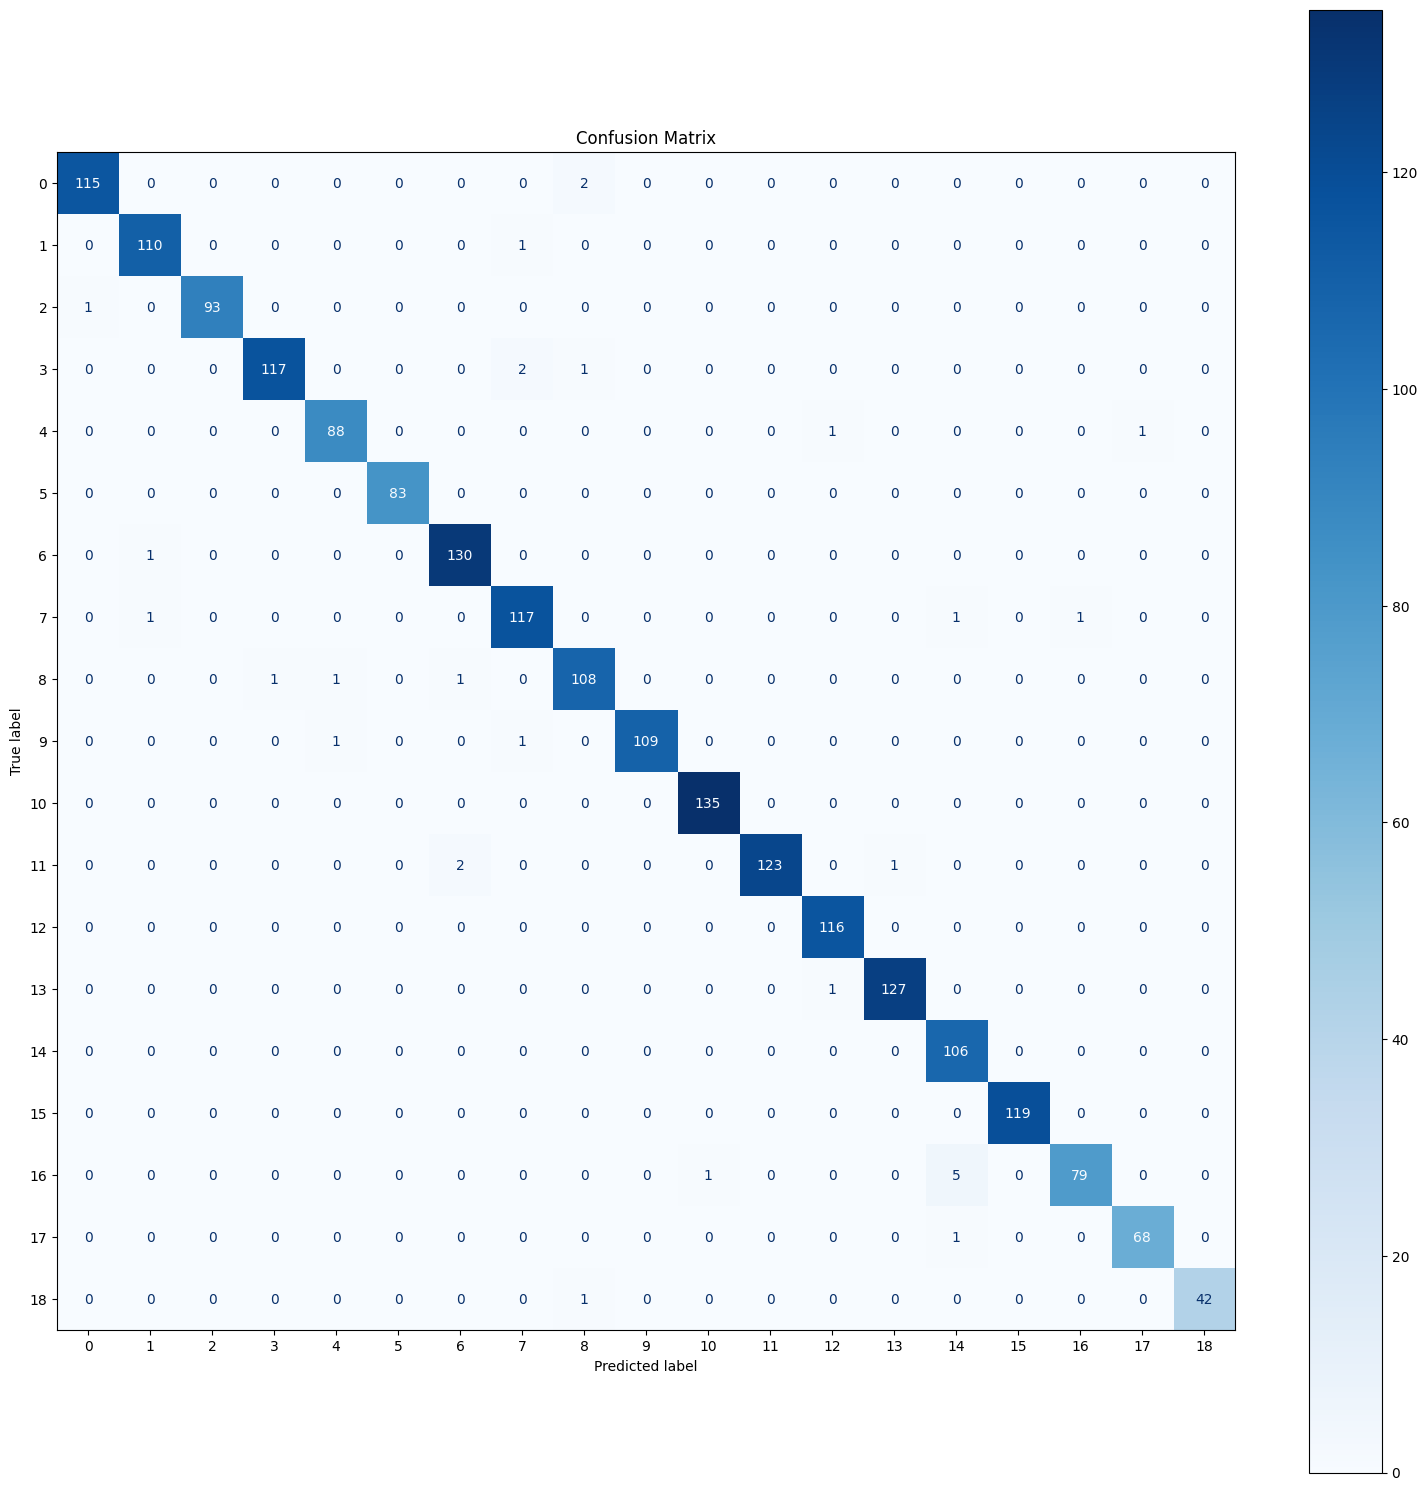

In [8]:
# confusion matrix

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(19)))

fig, ax = plt.subplots(figsize=(19, 19))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [10]:
import torch
import onnx
from huggingface_hub import HfApi

# 1. Export
dummy_input = torch.randn(1, 1, 32, 32).to(device)
torch.onnx.export(
    model,
    dummy_input,
    "cnn_single.onnx",
    dynamo=True,
    input_names=["input"],
    output_names=["output"],
)

# 2. Merge into single file
model_proto = onnx.load("cnn_single.onnx")
onnx.save(model_proto, "cnn_single.onnx", save_as_external_data=False)

# 3. Upload to Hugging Face
api = HfApi()
api.upload_file(
    path_or_fileobj="cnn_single.onnx",
    path_in_repo="cnn_single.onnx",
    repo_id="booogiee/math_cnn",
    repo_type="model"
)

print("Done!")

[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Users\Alex\AppData\Local\Programs\Python\Python313\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


cnn_single.onnx: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.00M/1.00M [00:00<00:00, 2.71MB/s]


Done!
